# init

In [1]:
%load_ext autoreload
%autoreload 2

# part 1

In [3]:
import os
import sys
import env
import src.utils.engine as engine

import numpy as np
from PIL import Image, ImageDraw

import matplotlib.pyplot as plt

from src.p1_edge_identification import *

pygame 2.6.1 (SDL 2.28.4, Python 3.11.2)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [4]:
image = Image.open(env.p1.chessboard_path)
image = ContourImage(image)
binary_image = image.prepare()
foreground = 0

In [5]:
# use Sobel operator for edge detection
def convolve(image, kernel):
    rows, cols = image.shape
    output = np.zeros_like(image)

    k_size = kernel.shape[0] // 2
    for i in range(k_size, rows - k_size):
        for j in range(k_size, cols - k_size):
            window = image[i-k_size:i+k_size+1, j-k_size:j+k_size+1]
            output[i, j] = abs(np.sum(window * kernel))  # Sum weighted region

    return output

sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
])
sobel_y = sobel_x.transpose()

binary_image_array = np.array(binary_image)

foreground_mask = (binary_image_array == foreground) * 255

edges_x = convolve(foreground_mask, sobel_x)
edges_y = convolve(foreground_mask, sobel_y)
edges = np.sqrt(edges_x**2 + edges_y**2)
edges = (edges / edges.max()) * 255 # normalize to pixel range

height, width = edges.shape
edge_coordinates = [(y, x) for x in range(width) for y in range(height)
                    if edges[y, x] > BINARIZE_THRESHOLD]


KeyboardInterrupt: 

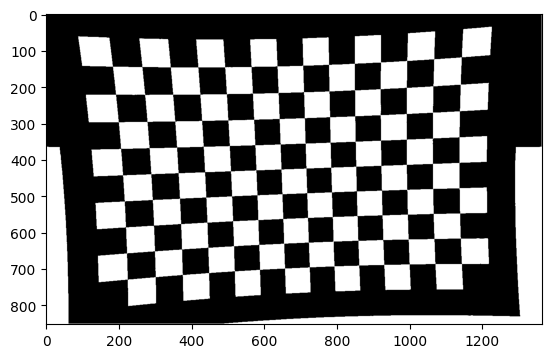

In [ ]:
plt.imshow(foreground_mask, cmap="gray")

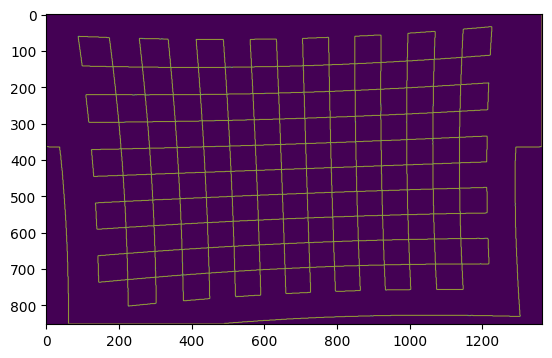

In [ ]:
plt.imshow(edges)

In [ ]:
max(edge_coordinates)

(1363, 851)

# part 2

In [5]:
import os
import sys
import env
import src.utils.utils as utils

import numpy as np
from PIL import Image
import cv2
import matplotlib.pyplot as plt

from src.p2_calibrate_camera import *

In [6]:
image = Image.open("data/p1_edge_identification/chessboard.png")
image_array = np.array(image)
image_array.shape
height, width, channels = image_array.shape

In [11]:
print(height/2, width/2, channels)

426.5 682.5 3


In [12]:
fov = 45 * (np.pi / 180)
f_r = 1 / (2 * np.tan(fov / 2))
f_x = f_y = f_r * min(height, width)
print(f_x)
print(f_y)
print(f_r)

1029.662084352125
1029.662084352125
1.2071067811865475


In [5]:
if not os.path.exists(env.p2.output):
    os.makedirs(env.p2.output)
expected_camera_matrix = np.load(env.p2.expected_camera_matrix)
expected_dist_coeffs = np.load(env.p2.expected_dist_coeffs)
# Part 2.a
ideal_intrinsic_matrix = np.array([
    [237.9237668337108, 0, 0],
    [0, 237.9237668337108, 0],
    [0, 0, 1]
])


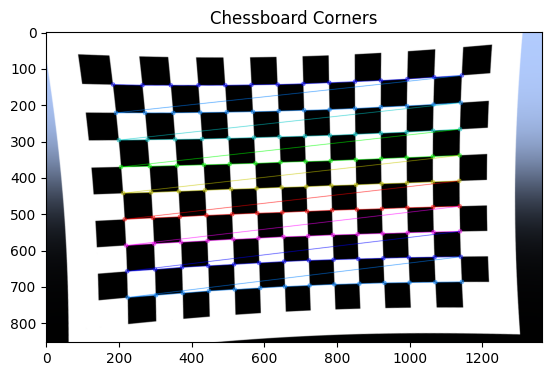

In [6]:
# Part 2.b
chessboard_size = (14, 9)  # (columns, rows)

image = utils.load_image(env.p1.chessboard_path)
grayscale_image = load_grayscale_image(image)
corners = find_chessboard_corners(grayscale_image, chessboard_size)
corners = refine_corners(grayscale_image, corners)
draw_corners(image, chessboard_size, corners)
# Image.fromarray(image).save(env.p2.chessboard_corners)

In [7]:
# Part 2.c
object_points = get_3D_object_points(chessboard_size)
camera_matrix, dist_coeffs = calibrate_camera(object_points, corners, grayscale_image.shape[::-1])
print("Camera Matrix:")
print(camera_matrix)
assert np.allclose(camera_matrix, expected_camera_matrix, atol=1e-2), f"Camera matrix does not match this expected matrix:\n{expected_camera_matrix}"
np.save(env.p2.camera_matrix, camera_matrix)
print("\nDistortion Coefficients:")
print(dist_coeffs)
assert np.allclose(dist_coeffs, expected_dist_coeffs, atol=1e-2), f"Distortion coefficients do not match these expected coefficients:\n{expected_dist_coeffs}"
np.save(env.p2.dist_coeff, dist_coeffs)

Camera Matrix:
[[993.65294903   0.         681.35765293]
 [  0.         993.67439378 423.52609889]
 [  0.           0.           1.        ]]

Distortion Coefficients:
[[ 0.18381107  0.03426184 -0.00056748 -0.00021095  0.0139307 ]]


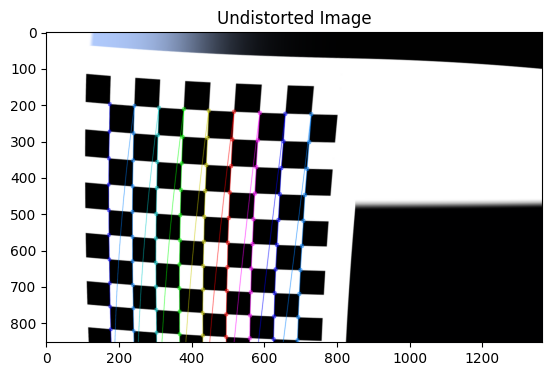

In [10]:
# Part 2.d
undistorted_image = undistort_image(image, camera_matrix, dist_coeffs)
plt.imshow(undistorted_image)
plt.title("Undistorted Image")
plt.show()
Image.fromarray(undistorted_image).save(env.p2.undistorted_image)

# part 3

In [6]:
import os
import sys
import env
import src.utils.utils as utils
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw

import numpy as np


In [7]:
if not os.path.exists(env.p3.output):
    os.makedirs(env.p3.output)
expected_F_LLS = np.load(env.p3.expected_F_LLS)
expected_dist_im1_LLS, expected_dist_im2_LLS = np.load(env.p3.expected_dist_LLS)

expected_F_normalized = np.load(env.p3.expected_F_normalized)
expected_dist_im1_normalized, expected_dist_im2_normalized = np.load(env.p3.expected_dist_normalized)

im1 = utils.load_image(env.p3.const_im1)
im2 = utils.load_image(env.p3.const_im2)

points1 = utils.load_points(env.p3.pts_1)
points2 = utils.load_points(env.p3.pts_2)
assert (points1.shape == points2.shape)

## 3.a

In [71]:
def lstsq_eight_point_alg(points1, points2):
    # [x1x2, x1y2, x1, y1x2, y1y2, y1, x2, y2, 1]
    N = points1.shape[0]
    W = np.zeros((N, 9))
    for i in range(N):
        x1, y1, _ = points1[i]
        x2, y2, _ = points2[i]
        W[i] = [
            x1*x2, x1*y2, x1, y1*x2, y1*y2, y1, x2, y2, 1
        ]
    _, _, V_t = np.linalg.svd(W)
    F = V_t[-1].reshape((3,3)).T # estimate is the last singular column of V/last row of V_t
    # zero out smallest singular value to get rank 2 fundamental matrix
    U, S, V_t = np.linalg.svd(F)
    S[-1] = 0
    F = U @ np.diag(S) @ V_t

    return F

F = lstsq_eight_point_alg(points1, points2)
F

array([[ 4.62218346e-08,  1.05738870e-06,  1.07962334e-04],
       [ 3.12366562e-06,  1.54915336e-07,  3.01697803e-02],
       [-1.04501739e-03, -3.46290906e-02,  9.98944196e-01]])

In [70]:
F_lls = lstsq_eight_point_alg(points1, points2)
print("Fundamental Matrix from LLS  8-point algorithm:\n", F_lls)
assert np.allclose(F_lls, expected_F_LLS, atol=1e-2), f"Fundamental matrix does not match this expected matrix:\n{expected_F_LLS}"

Fundamental Matrix from LLS  8-point algorithm:
 [[ 4.62218346e-08  3.12366562e-06 -1.04501739e-03]
 [ 1.05738870e-06  1.54915336e-07 -3.46290906e-02]
 [ 1.07962334e-04  3.01697803e-02  9.98944196e-01]]


AssertionError: Fundamental matrix does not match this expected matrix:
[[ 4.62218346e-08  1.05738870e-06  1.07962334e-04]
 [ 3.12366562e-06  1.54915336e-07  3.01697803e-02]
 [-1.04501739e-03 -3.46290906e-02  9.98944196e-01]]

## 3.b

In [59]:
def normalized_eight_point_alg(points1: np.array, points2: np.array) -> np.array:
    '''
    Computes the fundamental matrix from matching points
    using the normalized eight point algorithm
    Arguments:
        points1 - N points in the first image that match with points2
        points2 - N points in the second image that match with points1

        Both points1 and points2 are from the get_data_from_txt_file() method
    Returns:
        F - the fundamental matrix such that (points2)^T * F * points1 = 0
    Please see lecture notes and slides to see how the normalized eight
    point algorithm works
    '''
    def normalize_points(points):
        """
        Assumes points are in homogenous form.
        Return normalized points and transformation matrix T
        """

        centroid = np.mean(points[:, :-1], axis=0)
        mean_dist = np.mean(np.linalg.norm(
            points[:, :-1] - centroid,
            axis=1
        ))
        dist_scale = np.sqrt(2) / mean_dist

        T = np.array([
            [dist_scale, 0, -dist_scale * centroid[0]],
            [0, dist_scale, -dist_scale * centroid[1]],
            [0, 0, 1]
        ])

        normalized_points = points @ T.T
        return normalized_points, T

    normalized_points1, T_1 = normalize_points(points1)
    normalized_points2, T_2 = normalize_points(points2)

    # get estimated fundamental matrix with normalized points
    F_normalized = lstsq_eight_point_alg(normalized_points1, normalized_points2)

    # denormalize F
    F = T_2.T @ F_normalized @ T_1
    return F

F = normalized_eight_point_alg(points1, points2)
F

array([[ 3.53950141e-09,  2.57895217e-07, -8.55646318e-05],
       [ 7.66613225e-08,  1.02858549e-08, -2.86517523e-03],
       [ 6.97097597e-06,  2.36049542e-03,  1.67728504e-01]])

## 3.c

In [64]:
def compute_epipolar_lines(points: np.array, F: np.array) -> np.array:
    """
    Computes the epipolar lines in homogenous coordinates
    given matching points in two images and the fundamental matrix
    Arguments:
        points - N points in the first image that match with points2
        F - the Fundamental matrix such that (points1)^T * F * points2 = 0
    Returns:
        lines - the epipolar lines in homogenous coordinates
    """
    lines_standard = np.stack([F.dot(p) for p in points])
    A, B, C = lines_standard[:, 0], lines_standard[:, 1], lines_standard[:, 2]
    m = -A / B
    b = -C / B

    lines_slopeint = np.stack((m, b), axis=1)

    return lines_slopeint

In [65]:
l = compute_epipolar_lines(points1, F)
l

array([[-0.03576572, -1.96423428],
       [-0.03031625, -1.96968375],
       [-0.02741291, -1.97258709],
       [-0.07873514, -1.92126486],
       [-0.07687805, -1.92312195],
       [-0.11053316, -1.88946684],
       [-0.09020732, -1.90979268],
       [-0.11066635, -1.88933365],
       [-0.08884914, -1.91115086],
       [-0.07509673, -1.92490327],
       [-0.06568408, -1.93431592],
       [-0.13704116, -1.86295884],
       [-0.13884936, -1.86115064],
       [-0.14075554, -1.85924446],
       [-0.11845103, -1.88154897],
       [-0.10287081, -1.89712919],
       [-0.09148133, -1.90851867],
       [-0.15334329, -1.84665671],
       [-0.15558195, -1.84441805],
       [-0.15791855, -1.84208145],
       [-0.13716443, -1.86283557],
       [-0.12173913, -1.87826087],
       [-0.10971629, -1.89028371]])

# part 4

In [2]:
import os
import sys
import env
import src.utils.utils as utils

from PIL import Image

import numpy as np
import cv2
from src.p3_fundamental_matrix import *
import matplotlib.pyplot as plt

from pathlib import Path

# PROJECT_DIR = Path(__file__).resolve().parent

from src.p4_image_rectification import *

In [3]:
if not os.path.exists(env.p4.output):
    os.makedirs(env.p4.output)
expected_e1, expected_e2 = np.load(env.p4.expected_e1), np.load(env.p4.expected_e2)
expected_H1, expected_H2 = np.load(env.p4.expected_H1), np.load(env.p4.expected_H2)
im1 = utils.load_image(env.p3.const_im1)
im2 = utils.load_image(env.p3.const_im2)

points1 = utils.load_points(env.p3.pts_1)
points2 = utils.load_points(env.p3.pts_2)
assert (points1.shape == points2.shape)
F = normalized_eight_point_alg(points1, points2)

## 4.a

In [4]:
def compute_epipole(points1: np.array,
                    points2: np.array,
                    F: np.array) -> np.array:
    '''
    Computes the epipole in homogenous coordinates
    given matching points in two images and the fundamental matrix
    Arguments:
        points1 - N points in the first image that match with points2
        points2 - N points in the second image that match with points1
        F - the Fundamental matrix such that (points1)^T * F * points2 = 0

        Both points1 and points2 are from the get_data_from_txt_file() method
    Returns:
        epipole - the homogenous coordinates [x y 1] of the epipole in the image
    '''
    # epipole is the right null space of F
    U, S, V_t = np.linalg.svd(F)
    e = V_t[-1] # last row of V.T, or last column of V
    e_normalized = e / e[-1] # normalize so last coord of epipole is 1

    return e_normalized

In [5]:
# Part 4.a
e1 = compute_epipole(points1, points2, F)
e2 = compute_epipole(points2, points1, F.transpose())
print("e1", e1)
print("e2", e2)
assert np.allclose(e1, expected_e1, rtol=1e-2), f"e1 does not match this expected value:\n{expected_e1}"
assert np.allclose(e2, expected_e2, rtol=1e-2), f"e2 does not match this expected value:\n{expected_e2}"
np.save(env.p4.e1, e1)
np.save(env.p4.e2, e2)

e1 [-9.46327147e+03  3.25359204e+02  1.00000000e+00]
e2 [ 3.64222502e+04 -1.60809341e+02  1.00000000e+00]


## 4.b

In [11]:
H1, H2 = compute_matching_homographies(e2, F, im2, points1, points2)
print("H1:\n", H1)
print
print("H2:\n", H2)
assert np.allclose(H1, expected_H1, rtol=1e-2), f"H1 does not match this expected value:\n{expected_H1}"
assert np.allclose(H2, expected_H2, rtol=1e-2), f"H2 does not match this expected value:\n{expected_H2}"


H1:
 [[ 9.26616161e-01  1.39815130e-02  7.96385287e+01]
 [-1.34896446e+05 -1.34797938e+05 -1.38248136e+05]
 [ 3.72977161e+04  3.72977069e+04  3.73890110e+04]]
H2:
 [[ 9.70867986e-01 -2.02084735e-02  4.14712634e+01]
 [ 4.54540060e-03  1.00012199e+00 -4.72475860e+00]
 [-2.82377497e-05  5.87764583e-07  1.02857690e+00]]


<string>:30: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.


AssertionError: H1 does not match this expected value:
[[ 1.02660729e+02  2.07907964e+00 -6.13266953e+03]
 [ 2.96490114e+00  9.59516079e+01 -3.16082071e+03]
 [ 9.12194551e-03  4.20134022e-04  8.61862794e+01]]

## 4.c

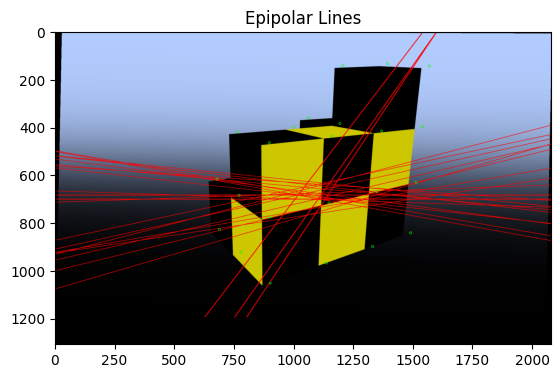

In [ ]:
# Part 4.c
rectified_im1, offset1 = compute_rectified_image(im1, H1)
rectified_im2, offset2 = compute_rectified_image(im2, H2)

new_points1 = H1.dot(points1.T)
new_points2 = H2.dot(points2.T)
new_points1 /= new_points1[2,:]
new_points2 /= new_points2[2,:]
new_points1 = new_points1.T
new_points2 = new_points2.T
new_points1 -= offset1 + (0,)
new_points2 -= offset2 + (0,)
total_offset_y = np.mean(new_points1[:, 1] - new_points2[:, 1]).round()

F_new = normalized_eight_point_alg(new_points1, new_points2)
lines1 = compute_epipolar_lines(new_points2, F_new.T)
lines2 = compute_epipolar_lines(new_points1, F_new)
aligned_img = show_epipolar_imgs(rectified_im1, rectified_im2, lines1, lines2, new_points1, new_points2, offset=int(total_offset_y))
Image.fromarray(aligned_img).save(env.p4.aligned_epipolar)

## 4.d

In [ ]:
# Part 4.d
im1 = utils.load_image(env.p3.const_im1)
im2 = utils.load_image(env.p3.const_im2)
kp1, kp2, good_matches = find_matches(im1, im2)
cv_matches = show_matches(im1, im2, kp1, kp2, good_matches)
Image.fromarray(cv_matches).save(env.p4.cv_matches)

# 5

In [2]:
import os
import sys
import env
import src.utils.engine as engine
import src.utils.utils as utils
from typing import List, Tuple

from src.p2_calibrate_camera import *
from src.p4_image_rectification import *

import numpy as np
import shutil
from tqdm import tqdm
import matplotlib.pyplot as plt

from src.p5_3D_reconstruction import *

pygame 2.6.1 (SDL 2.28.4, Python 3.11.2)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
if not os.path.exists(env.p5.output):
    os.makedirs(env.p5.output)
expected_R = np.load(env.p5.expected_R)
expected_T = np.load(env.p5.expected_T)

chessboard_size = (16, 10)  # (columns, rows)
import argparse
parser = argparse.ArgumentParser()
parser.add_argument('--setup', action='store_true')
args = parser.parse_args()
setup = args.setup

if setup:
    engine.get_chessboard(env.p5.chessboard)
    engine.get_object_images(env.p5.arc_obj, env.p5.arc_texture, env.p5.raw_images, views=5)  # may take a while; has many vertices!

camera_matrix, dist_coeffs = calibrate_camera_from_chessboard(env.p5.chessboard, chessboard_size)

im1 = utils.load_image(env.p5.raw_images / 'object_0.png')
im2 = utils.load_image(env.p5.raw_images / 'object_1.png')

kp1, kp2, good_matches = find_matches(im1, im2)
show_matches(im1, im2, kp1, kp2, good_matches)

# Part 5.a
fundamental_matrix, mask, pts1, pts2 = recover_fundamental_matrix(kp1, kp2, good_matches)
inlier_pts1, inlier_pts2 = get_inliers(mask, pts1, pts2)

usage: ipykernel_launcher.py [-h] [--setup]
ipykernel_launcher.py: error: unrecognized arguments: --f=/Users/vincentlin246/Library/Jupyter/runtime/kernel-v3b79025b5cdf1c965b42b8b61be4747bd29ebfd28.json


SystemExit: 2

/Users/vincentlin246/git/6.8300/pset3/venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3554: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [4]:
%tb

SystemExit: 2

In [ ]:
# Part 5.b
essential_matrix = compute_essential_matrix(camera_matrix, fundamental_matrix)

In [ ]:
# Part 5.c
R, T = estimate_initial_RT(essential_matrix)
print
print("Estimated R:\n", R)
print("Estimated T:\n", T)

In [ ]:
# Part 5.d
R, T = find_best_RT(R, T, inlier_pts1, inlier_pts2, camera_matrix)
print
print("Best R:\n", R)
print("Best T:\n", T)
assert np.allclose(R, expected_R, atol=1e-2), f"R does not match this expected value:\n{expected_R}"
assert np.allclose(T, expected_T, atol=1e-2), f"T does not match this expected value:\n{expected_T}"

np.save(env.p5.rotation_matrix, R)
np.save(env.p5.translation_matrix, T)

In [ ]:
# Part 5.e
P1 = get_identity_projection_matrix(camera_matrix)
P2 = get_local_projection_matrix(camera_matrix, R, T)

pts4D_h = cv2.triangulatePoints(P1, P2, inlier_pts1, inlier_pts2)
pts3D = (pts4D_h[:3] / pts4D_h[3]).T
print(f"Triangulated {len(pts3D)} points.")
print("Example 3D point:", pts3D[0])

U, S, Vt = np.linalg.svd(fundamental_matrix)
print("Singular values of F:", S)

show_points_matplotlib(pts3D)

# test

In [13]:

w,h = 16,20
corners = np.array([
    [0, 0, 1], [w, 0, 1], [0, h, 1], [w, h, 1]
]).T  # 3x4 matrix


In [19]:
np.arange(9).reshape((3,3)) @ np.array([1,1,1])

array([ 3, 12, 21])